Loaded tickers: ['AAPL', 'AMZN', 'AXP', 'BAC', 'BLK', 'C', 'CAT', 'COST', 'CVX', 'DE', 'GOOGL', 'GS', 'JNJ', 'JPM', 'MA', 'META', 'MS', 'MSFT', 'NVDA', 'PFE', 'PYPL', 'SCHW', 'UNH', 'USB', 'V', 'WFC', 'WMT', 'XOM']
SMART PAIR SELECTION
AAPL/BAC half-life: 89.8
AAPL/BLK half-life: 83.2
AAPL/C half-life: 100.3
AAPL/DE half-life: 30.8
AAPL/MA half-life: 65.1
AAPL/MSFT half-life: 85.5
AAPL/UNH half-life: 43.5
AAPL/USB half-life: 53.4
AMZN/AXP half-life: 96.0
AMZN/BLK half-life: 43.5
AMZN/DE half-life: 27.8
AMZN/GOOGL half-life: 32.8
AMZN/JNJ half-life: 21.0
AMZN/MA half-life: 92.9
AMZN/V half-life: 94.5
AXP/GOOGL half-life: 54.2
AXP/JPM half-life: 48.3
AXP/MA half-life: 45.9
AXP/META half-life: 61.0
AXP/PFE half-life: 63.3
AXP/UNH half-life: 47.0
AXP/USB half-life: 101.6
AXP/V half-life: 50.5
AXP/WFC half-life: 24.1
Adaptive ENTRY: 1.41, EXIT: 0.38
Avg turnover: 0.17328519855595667
BAC/C half-life: 75.2
BAC/MS half-life: 34.6
BAC/USB half-life: 47.2
BAC/XOM half-life: 67.6
BLK/CVX half-lif

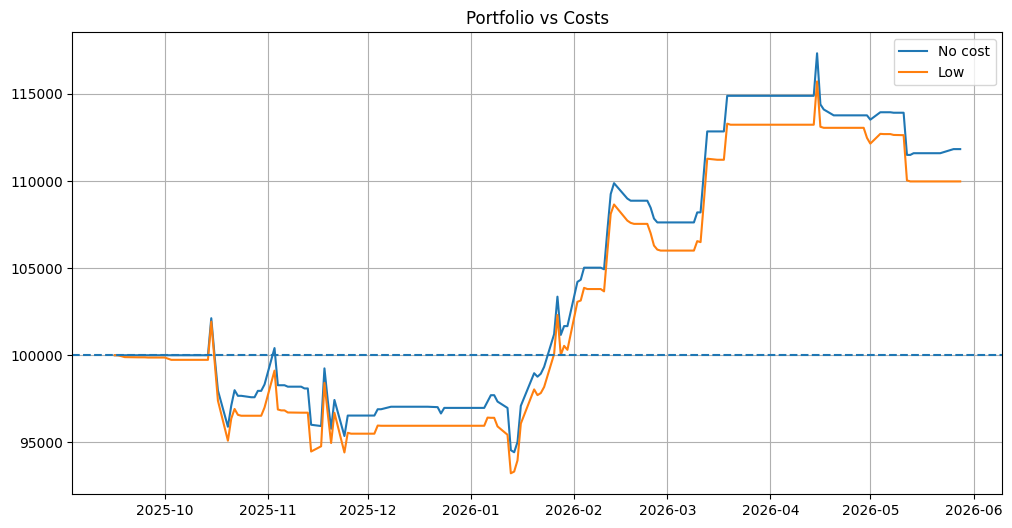

In [6]:

import numpy as np
#np.random.seed(42)
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.tsa.stattools import coint

#config
SECTORS = {
    "AAPL":"tech","MSFT":"tech","NVDA":"tech","GOOGL":"tech","META":"tech",
    "JPM":"finance","BAC":"finance","GS":"finance","C":"finance","WFC":"finance","MS":"finance","USB":"finance",
    "V":"payments","MA":"payments","AXP":"payments","PYPL":"payments",
    "BLK":"asset","SCHW":"asset",
    "XOM":"energy","CVX":"energy",
    "CAT":"industrial","DE":"industrial",
    "WMT":"retail","COST":"retail","AMZN":"retail",
    "JNJ":"health","PFE":"health","UNH":"health"
}

TICKERS = ["JPM","BAC","MS","GS","C","WFC","USB","V","MA","AXP","PYPL","BLK","SCHW",
    "AAPL","MSFT","GOOGL","META","NVDA","AMZN","WMT","COST","XOM","CVX","CAT","DE","JNJ","PFE","UNH"]
PERIOD = "5y"
ZSCORE_WINDOW = 60
#ENTRY = z.abs().quantile(0.95)
#EXIT = z.abs().quantile(0.50)
INITIAL_CAPITAL = 100000
TRAIN_PCT = 0.6
MAX_PAIRS = 5
COST_LEVELS = [
    ("No cost", 0.0, 0.0),
    ("Low", 0.0005, 0.0001),
    ("Medium", 0.001, 0.0002),
    ("High", 0.002, 0.0005),
]

#loading
def load_all():
    data = yf.download(
        TICKERS,
        period=PERIOD,
        progress=False,
        auto_adjust=True
    )["Close"]
    data = data.dropna(axis=1, how="all")
    print("Loaded tickers:", list(data.columns))
    return data.dropna()
#to find best pairs
def compute_thresholds(z):
    entry = z.abs().quantile(0.95)
    exit_ = z.abs().quantile(0.50)
    # entry = max(entry, 1.0)
    # exit_ = max(exit_, 0.1)
    entry = min(z.abs().quantile(0.85), 1.8)
    exit_ = min(z.abs().quantile(0.35), 0.5)
    print(f"Adaptive ENTRY: {entry:.2f}, EXIT: {exit_:.2f}")
    return entry, exit_

def compute_halflife(spread):
    spread_lag = spread.shift(1).dropna()
    spread_ret = spread.diff().dropna()
    spread_lag = spread_lag.loc[spread_ret.index]
    beta = np.polyfit(spread_lag, spread_ret, 1)[0]
    if beta >= 0:
        return np.inf
    hl = -np.log(2) / beta
    return hl

def find_pairs(data):
    print("SMART PAIR SELECTION")
    results = []
    for t1, t2 in combinations(data.columns, 2):
        if (t1 not in SECTORS) or (t2 not in SECTORS):
            continue
        if SECTORS[t1] != SECTORS[t2]:
            if np.random.rand() > 0.3:
                    continue
        pair = data[[t1,t2]].dropna()
        if len(pair) < 100:
            continue
        split = int(len(pair) * TRAIN_PCT)
        train = pair.iloc[:split]
        if len(train) < 50:
            continue
        test = pair.iloc[split:]
        y = train.iloc[:,1]
        x = train.iloc[:,0]
        beta = np.polyfit(x, y, 1)[0]
        spread = y - beta * x
        hl = compute_halflife(spread)
        if hl > 120:
            continue
        print(f"{t1}/{t2} half-life: {hl:.1f}")
        corr_train = train.iloc[:,0].corr(train.iloc[:,1])
        corr_test  = test.iloc[:,0].corr(test.iloc[:,1])
        if abs(corr_train - corr_test) > 0.7:
            continue
        _, p, _ = coint(train.iloc[:,0], train.iloc[:,1])
        if p > 0.1: #0.05:
            continue
        # backtest on train
        res = backtest_pair(train, 0, 0)
        if not res:
            continue
        _, sharpe, ret = res
        results.append((t1, t2, p, sharpe, ret))
    df = pd.DataFrame(results, columns=["T1","T2","p","Sharpe","Return"])
    df_full = df.copy()
    df = df.sort_values("Sharpe", ascending=False)
    if len(df) == 0:
        print("no pairs at all")
        return pd.DataFrame()
    df = df.head(MAX_PAIRS)
    #df = df[df["Sharpe"] > 0]
    #df = df[df["Return"] > 0]
    print("\nFiltered pairs:")
    print(df)
    return df.head(MAX_PAIRS)

# Kalman beta
def kalman_beta(y, x):
    n = len(y)
    beta = np.zeros(n)
    P = 1
    R = 0.001
    Q = 0.001
    for i in range(1, n):
        beta_pred = beta[i-1]
        P_pred = P + Q
        K = P_pred * x[i] / (x[i]**2 * P_pred + R)
        beta[i] = beta_pred + K * (y[i] - beta_pred * x[i])
        P = (1 - K * x[i]) * P_pred
    return beta

# Z-score
def zscore(spread):
    m = spread.rolling(ZSCORE_WINDOW).mean().shift(1)
    s = spread.rolling(ZSCORE_WINDOW).std().shift(1)
    return (spread - m) / s

# Signals
def get_positions(z, entry, exit_):
    pos = pd.Series(0, index=z.index)
    pos[z < -entry] = 1
    pos[z > entry] = -1
    pos[abs(z) < exit_] = 0
    pos = pos.ffill().fillna(0)
    return pos

# Backtest
# def backtest_pair(data, commission, slippage):
#     y = data.iloc[:,1].values
#     x = data.iloc[:,0].values
#     beta = pd.Series(kalman_beta(y,x), index=data.index)
#     beta = beta.rolling(5).mean()
#     beta = beta.clip(0.1, 5)
#     beta = beta.bfill()
#     spread = y - beta.values * x
#     spread = pd.Series(spread, index=data.index)
#     z = zscore(spread).dropna()
#     if len(z) < 100:
#         return None
#     split = int(len(z) * TRAIN_PCT)
#     z_train = z.iloc[:split]
#     z_test = z.iloc[split:]
#     if z_train.std() < 0.75:
#         print("Skip: weak z-score volatility")
#         return None
#     print("Z mean:", z_test.mean())
#     print("Z std:", z_test.std())
#     entry, exit_ = compute_thresholds(z_train)
#     pos = get_positions(z_test, entry, exit_)
#     df = data.loc[z_test.index].copy()
#     df["ret_x"] = df.iloc[:,0].pct_change()
#     df["ret_y"] = df.iloc[:,1].pct_change()
#     df["beta"] = beta.loc[z_test.index]
#     df["pos"] = pos
#     df = df.dropna()
#     safe_beta = df["beta"].clip(-0.9, 5)
#     w1 = -safe_beta
#     w2 = 1.0
#     norm = abs(w1) + abs(w2)
#     w1 = w1 / norm
#     w2 = w2 / norm
#     pos = pos.shift(1).fillna(0)
#     print("Trades:", pos.diff().abs().sum())
#     trades = pos.diff().abs().sum()
#     if trades < 3:
#         print("Skip: too few trades")
#         return None
#     strat = df["pos"] * (w2 * df["ret_y"] + w1 * df["ret_x"])
#     strat = strat.fillna(0)
#     strat = strat.clip(-0.05, 0.05)
#     if strat.mean() < 0:
#         print("Flip strategy direction")
#         strat = -strat
#     if strat.mean() <= 0:
#         print("Skip: negative strategy")
#         return None
#     print("Strategy mean:", strat.mean())
#     print("Strategy std:", strat.std())
#     turnover = pos.diff().abs()
#     costs = turnover * 2 * (commission + slippage)
#     strat = strat - costs
#     strat = strat.dropna()
#     if len(strat) < 2 or strat.std() == 0:
#         return None
#     if (strat < -0.5).any():
#         print("ERROR: extreme loss detected")
#         return None
#     equity = (1 + strat).cumprod()
#     if equity.iloc[-1] <= 0:
#         print("ERROR: equity collapsed")
#         return None
#     equity = equity.clip(lower=0.5)
#     equity = (1 + strat).cumprod() * INITIAL_CAPITAL
#     sharpe = np.sqrt(252) * strat.mean() / strat.std()
#     total = (equity.iloc[-1]/INITIAL_CAPITAL - 1) * 100
#     return equity, sharpe, total

def backtest_pair(data, commission, slippage):
    y = data.iloc[:,1].values
    x = data.iloc[:,0].values
    beta = pd.Series(kalman_beta(y,x), index=data.index)
    beta = beta.rolling(5).mean().bfill().clip(0.1, 5)
    spread = y - beta.values * x
    spread = pd.Series(spread, index=data.index)
    trend = spread.rolling(50).mean()
    trend_strength = trend.diff().abs().mean() / (spread.std() + 1e-6)
    if trend_strength > 2.0:
        return None
    z = zscore(spread).dropna()
    if len(z) < 100:
        return None
    split = int(len(z) * TRAIN_PCT)
    z_train = z.iloc[:split]
    z_test = z.iloc[split:]
    if z_train.std() < 0.75:
        return None
    entry, exit_ = compute_thresholds(z_train)

    #Train strategy
    pos_train = get_positions(z_train, entry, exit_)
    pos_train = pos_train.shift(1).fillna(0)
    df_train = data.loc[z_train.index].copy()
    df_train["ret_x"] = df_train.iloc[:,0].pct_change()
    df_train["ret_y"] = df_train.iloc[:,1].pct_change()
    df_train["beta"] = beta.loc[z_train.index]
    df_train["pos"] = pos_train
    df_train = df_train.dropna()
    safe_beta = df_train["beta"].clip(-0.9, 5)
    w1 = -safe_beta
    w2 = 1.0
    norm = abs(w1) + abs(w2)
    w1 /= norm
    w2 /= norm
    strat_train = df_train["pos"] * (w2 * df_train["ret_y"] + w1 * df_train["ret_x"])
    strat_train = strat_train.fillna(0).clip(-0.05, 0.05)
    direction = 1 if strat_train.mean() > 0 else -1 # only train

    #Test strategy
    pos = get_positions(z_test, entry, exit_)
    pos = pos.shift(1).fillna(0)
    trades = pos.diff().abs().sum()
    if trades < 5:
        return None
    df = data.loc[z_test.index].copy()
    df["ret_x"] = df.iloc[:,0].pct_change()
    df["ret_y"] = df.iloc[:,1].pct_change()
    df["beta"] = beta.loc[z_test.index]
    df["pos"] = pos
    df = df.dropna()
    safe_beta = df["beta"].clip(-0.9, 5)
    w1 = -safe_beta
    w2 = 1.0
    norm = abs(w1) + abs(w2)
    w1 /= norm
    w2 /= norm
    strat = df["pos"] * (w2 * df["ret_y"] + w1 * df["ret_x"])
    strat = strat.fillna(0).clip(-0.05, 0.05)   #before scaling
    strat = direction * strat
    target_vol = 0.02
    vol = strat.rolling(20).std()
    vol = vol.replace(0, np.nan)
    strat = strat * (target_vol / vol)
    strat = strat.fillna(0).clip(-0.05, 0.05) #after scaling
    turnover = pos.diff().abs()
    print("Avg turnover:", turnover.mean())
    costs = turnover * 2 * (commission + slippage)
    strat = strat - costs
    if strat.mean() < -0.0005:
        return None
    if (strat < -0.5).any():
        return None
    equity = (1 + strat).cumprod()
    if equity.iloc[-1] <= 0:
        return None
    equity = equity * INITIAL_CAPITAL
    sharpe = np.sqrt(252) * strat.mean() / strat.std()
    total = (equity.iloc[-1] / INITIAL_CAPITAL - 1) * 100
    return equity, sharpe, total

# Portfolio
def run():
    data = load_all()
    pairs = find_pairs(data)
    results_all = []
    equity_all = {}
    for name, commission, slippage in COST_LEVELS:
        print(f"\n=== {name} ===")
        eqs = []
        sharpes = []
        totals = []
        if pairs.empty:
            print("No valid pairs found → skip this run")
            return
        for _, row in pairs.iterrows():
            t1, t2, p = row["T1"], row["T2"], row["p"]
            pair_data = data[[t1,t2]]
            split = int(len(pair_data)*TRAIN_PCT)
            train = pair_data.iloc[:split]
            test = pair_data.iloc[split:]
            # score, pval, _ = coint(train.iloc[:,0], train.iloc[:,1])
            # print(f"{t1}/{t2} p={pval:.4f}")
            # match = (SECTORS[t1] == SECTORS[t2])
            # if match:
            #     if pval > 0.1:
            #         print("skip")
            #         continue
            # else:
            #     if pval > 0.05:
            #         print("skip")
            #         continue
            pval = row["p"]
            print(f"{t1}/{t2} p={pval:.4f} (pre-selected)")
            res = backtest_pair(test, commission, slippage)
            if res:
                eq, sh, tot = res
                eqs.append(eq)
                sharpes.append(sh)
                totals.append(tot)
        # if len(eqs) == 0:
        #     print("No valid strategies in portfolio")
        #     continue
        if len(eqs) < 3:
              print("Too concentrated → skip portfolio")
              continue
        weights = np.array(sharpes)
        # weights = np.maximum(weights, 0)
        # weights = weights ** 2
        vols = []
        for eq in eqs:
            ret = eq.pct_change().dropna()
            vols.append(ret.std())
        vols = np.array(vols)
        weights = weights / (vols + 1e-6)
        weights = np.nan_to_num(weights)
        weights = np.maximum(weights, 0)
        weights = np.clip(weights, 0, 0.4)
        weights = weights / weights.sum()
        weights = 0.7 * weights + 0.3 / len(weights)
        all_index = sorted(set().union(*[eq.index for eq in eqs]))
        aligned = []
        for eq in eqs:
            eq_aligned = eq.reindex(all_index)
            eq_aligned = eq_aligned.ffill().bfill()
            aligned.append(eq_aligned)
        combined = pd.concat(aligned, axis=1)
        #combined = pd.concat(eqs, axis=1)
        #combined = combined.fillna(method="ffill").dropna()
        #combined = combined.fillna(method="ffill")
        #combined = combined.fillna(method="bfill")
        print("Portfolio columns:", combined.shape[1])
        print("Valid strategies:", len(eqs))
        # port = (combined * weights).sum(axis=1)
        # ret = (port.iloc[-1]/INITIAL_CAPITAL - 1) * 100
        # port_ret = port.pct_change().dropna()
        returns = combined.pct_change().dropna()
        port_ret = (returns * weights).sum(axis=1)
        port = (1 + port_ret).cumprod() * INITIAL_CAPITAL
        total = (port.iloc[-1] / INITIAL_CAPITAL - 1) * 100
        sharpe = np.sqrt(252) * port_ret.mean() / port_ret.std()
        print(f"Portfolio Return: {total:.2f}%")
        print(f"Portfolio Sharpe: {sharpe:.3f}")
        results_all.append({
            "Scenario": name,
            "Return %": round(total, 2),
            "Sharpe": round(sharpe, 3),
            "Pairs used": len(eqs)
        })
        equity_all[name] = port
    df = pd.DataFrame(results_all)
    print("\n=== FINAL TABLE ===")
    print(df.to_string(index=False))
    plot(equity_all)

#Plot
def plot(eqs):
    plt.figure(figsize=(12,6))
    for name, eq in eqs.items():
        plt.plot(eq, label=name)
    plt.legend()
    plt.axhline(INITIAL_CAPITAL, linestyle="--")
    plt.title("Portfolio vs Costs")
    plt.grid()
    plt.show()

#Main
if __name__ == "__main__":
    run()